In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch is using: {torch.version.cuda}")
print(f"Is the GPU recognized? {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA version PyTorch is using: 13.0
Is the GPU recognized? True


In [2]:
import os
import gc
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    cohen_kappa_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.transforms import InterpolationMode

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


## Configuration

In [3]:
ZIP_PATH = Path("train_processed_final.zip")
LABELS_CSV = Path("trainLabels.csv")
EXTRACT_DIR = Path("train_processed_data")
MODEL_SAVE_PATH = Path("best_convnext_tiny.pth")
HISTORY_SAVE_PATH = Path("training_history.csv")

SEED = 42
NUM_CLASSES = 5

IMG_SIZE = 320
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * GRAD_ACCUM_STEPS

NUM_EPOCHS = 18
BACKBONE_FREEZE_EPOCHS = 1
EARLY_STOPPING_PATIENCE = 5

LR_BACKBONE = 2e-5
LR_HEAD = 1e-4
WEIGHT_DECAY = 2e-4
LABEL_SMOOTHING = 0.03
ORDINAL_LOSS_WEIGHT = 0.15
MAX_GRAD_NORM = 1.0

USE_CLASS_WEIGHTED_LOSS = True
USE_ORDINAL_REGULARIZATION = True
ENABLE_THRESHOLD_TUNING = True
USE_CHANNELS_LAST = True

VAL_SIZE = 0.2
NUM_WORKERS = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print(f"IMG_SIZE={IMG_SIZE}, batch={BATCH_SIZE}, accum={GRAD_ACCUM_STEPS}, effective_batch={EFFECTIVE_BATCH_SIZE}")

Using device: cuda
IMG_SIZE=320, batch=4, accum=4, effective_batch=16


In [4]:
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [5]:
labels_df = pd.read_csv(LABELS_CSV)
print(labels_df.head())
print(labels_df.columns.tolist())

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
['image', 'level']


## Image path mapping

In [6]:
image_files = list(EXTRACT_DIR.rglob("*.jpg")) + list(EXTRACT_DIR.rglob("*.jpeg")) + list(EXTRACT_DIR.rglob("*.png"))
print("Total extracted image files:", len(image_files))
image_map = {img.stem: img for img in image_files}
print("Mapped image stems:", len(image_map))

Total extracted image files: 35126
Mapped image stems: 35126


## Match labels with available images

In [7]:
labels_df["image_path"] = labels_df["image"].map(image_map)
labels_df = labels_df.dropna(subset=["image_path"]).copy()

labels_df["image_path"] = labels_df["image_path"].astype(str)
labels_df["level"] = labels_df["level"].astype(int)

print("Matched samples:", len(labels_df))
print(labels_df["level"].value_counts().sort_index())
labels_df.head()

Matched samples: 35126
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


,image,level,image_path
0,10_left,0,train_processed_data/10_left.jpg
1,10_right,0,train_processed_data/10_right.jpg
2,13_left,0,train_processed_data/13_left.jpg
3,13_right,0,train_processed_data/13_right.jpg
4,15_left,1,train_processed_data/15_left.jpg


In [8]:
train_df, val_df = train_test_split(
    labels_df,
    test_size = VAL_SIZE,
    stratify = labels_df["level"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 28100
Val size: 7026


In [9]:
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv", index=False)

In [10]:
train_df = pd.read_csv("train_dataset.csv")   
val_df = pd.read_csv("val_dataset.csv")   

## Data Augmentation

In [11]:
train_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.08), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.92, 1.0),
        ratio=(0.95, 1.05),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.08,
            contrast=0.08,
            saturation=0.03,
            hue=0.01
        )
    ], p=0.5),
    transforms.RandomAffine(
        degrees=8,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.05), interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## Creating Dataset

In [12]:
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = int(self.df.iloc[idx]["level"])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to load image: {img_path}") from e
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = DRDataset(train_df, transform=train_transform)
val_dataset = DRDataset(val_df, transform=val_transform)

## Handling Class Imbalance
Ref: <href>https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/</href>

In [13]:
class_counts = (
    train_df["level"]
    .value_counts()
    .sort_index()
    .reindex(range(NUM_CLASSES), fill_value=0)
    .values
)

# Sqrt inverse-frequency weighting is usually more stable than raw inverse
# frequency on this dataset and avoids over-pulling minority classes.
class_weights_np = np.sqrt(class_counts.sum() / np.clip(class_counts, a_min=1, a_max=None))
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=DEVICE)

plain_ce = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
weighted_ce = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

print("Class counts:", class_counts.tolist())
print("Class weights:", class_weights.detach().cpu().numpy().round(3).tolist())
print("Using class-weighted loss with shuffle=True. WeightedRandomSampler stays off for better probability calibration and more stable QWK.")

Class counts: [20648, 1954, 4234, 698, 566]
Class weights: [0.27900001406669617, 0.906000018119812, 0.6159999966621399, 1.5160000324249268, 1.684000015258789]
Using class-weighted loss with shuffle=True. WeightedRandomSampler stays off for better probability calibration and more stable QWK.


## Data Loaders
Ref: <href>https://docs.pytorch.org/docs/stable/data.html</href>

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0)
)

## Loading ConvNeXt-Tiny
Using pre-trained weights

In [15]:
weights = ConvNeXt_Tiny_Weights.DEFAULT

def build_model(num_classes=NUM_CLASSES):
    model = convnext_tiny(weights=weights)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=0.20),
        nn.Linear(in_features, num_classes)
    )
    return model

def set_backbone_trainable(model, trainable=True):
    for param in model.features.parameters():
        param.requires_grad = trainable
    for param in model.classifier.parameters():
        param.requires_grad = True

model = build_model().to(DEVICE)
if USE_CHANNELS_LAST and DEVICE.type == "cuda":
    model = model.to(memory_format=torch.channels_last)
set_backbone_trainable(model, trainable=False)
print(model)
print("Backbone frozen for warm-up epoch(s):", BACKBONE_FREEZE_EPOCHS)


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

## Loss, Optimizer, Scheduler, Mixed Precision

In [16]:
class OrdinalAwareLoss(nn.Module):
    def __init__(self, num_classes, class_weights=None, label_smoothing=0.0, ordinal_weight=0.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=label_smoothing
        )
        self.ordinal_weight = ordinal_weight
        self.register_buffer("class_values", torch.arange(num_classes, dtype=torch.float32))

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)

        if self.ordinal_weight <= 0:
            return ce_loss

        probs = torch.softmax(logits, dim=1)
        class_values = self.class_values.to(device=logits.device, dtype=probs.dtype)
        expected_scores = (probs * class_values.unsqueeze(0)).sum(dim=1)
        ordinal_loss = F.smooth_l1_loss(expected_scores, targets.float())
        return ce_loss + self.ordinal_weight * ordinal_loss

def build_criterion():
    loss_weights = class_weights if USE_CLASS_WEIGHTED_LOSS else None
    ordinal_weight = ORDINAL_LOSS_WEIGHT if USE_ORDINAL_REGULARIZATION else 0.0
    return OrdinalAwareLoss(
        num_classes=NUM_CLASSES,
        class_weights=loss_weights,
        label_smoothing=LABEL_SMOOTHING,
        ordinal_weight=ordinal_weight
    )

criterion = build_criterion().to(DEVICE)

optimizer = optim.AdamW(
    [
        {"params": model.features.parameters(), "lr": LR_BACKBONE},
        {"params": model.classifier.parameters(), "lr": LR_HEAD},
    ],
    weight_decay=WEIGHT_DECAY
)

warmup_scheduler = optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.25,
    total_iters=max(1, BACKBONE_FREEZE_EPOCHS)
)
cosine_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=max(1, NUM_EPOCHS - BACKBONE_FREEZE_EPOCHS),
    eta_min=1e-6
)
scheduler = optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[max(1, BACKBONE_FREEZE_EPOCHS)]
)

scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

print("Loss config:")
print("  Plain CE available for ablation via plain_ce")
print("  Weighted CE available for ablation via weighted_ce")
print(f"  Training criterion uses class weights={USE_CLASS_WEIGHTED_LOSS}, ordinal regularization={USE_ORDINAL_REGULARIZATION}")

Loss config:
  Plain CE available for ablation via plain_ce
  Weighted CE available for ablation via weighted_ce
  Training criterion uses class weights=True, ordinal regularization=True


## Model Training

In [17]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

def compute_metrics(y_true, y_pred):
    return {
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "qwk": quadratic_weighted_kappa(y_true, y_pred),
    }

def sanitize_thresholds(thresholds, min_gap=1e-3):
    thresholds = np.asarray(thresholds, dtype=np.float32).copy()
    thresholds.sort()

    for idx in range(1, len(thresholds)):
        if thresholds[idx] <= thresholds[idx - 1] + min_gap:
            thresholds[idx] = thresholds[idx - 1] + min_gap

    thresholds = np.clip(thresholds, -0.5, NUM_CLASSES - 0.5)

    for idx in range(len(thresholds) - 2, -1, -1):
        max_allowed = thresholds[idx + 1] - min_gap
        if thresholds[idx] >= max_allowed:
            thresholds[idx] = max_allowed

    return thresholds

def apply_thresholds(expected_scores, thresholds):
    thresholds = sanitize_thresholds(thresholds)
    return np.digitize(expected_scores, bins=thresholds).astype(int)

def optimize_thresholds(y_true, expected_scores, initial_thresholds=None, start_step=0.25, min_step=0.01):
    y_true = np.asarray(y_true, dtype=np.int64)
    expected_scores = np.asarray(expected_scores, dtype=np.float32)

    thresholds = sanitize_thresholds(
        initial_thresholds if initial_thresholds is not None else [0.5, 1.5, 2.5, 3.5]
    )
    best_qwk = quadratic_weighted_kappa(y_true, apply_thresholds(expected_scores, thresholds))
    step = start_step

    while step >= min_step:
        improved = False

        for idx in range(len(thresholds)):
            lower = thresholds[idx - 1] + 1e-3 if idx > 0 else -0.5
            upper = thresholds[idx + 1] - 1e-3 if idx < len(thresholds) - 1 else NUM_CLASSES - 0.5

            if upper <= lower:
                continue

            candidates = np.arange(
                max(lower, thresholds[idx] - (2 * step)),
                min(upper, thresholds[idx] + (2 * step)) + (step * 0.5),
                step,
                dtype=np.float32
            )

            local_best = thresholds[idx]
            local_best_qwk = best_qwk

            for candidate in candidates:
                trial = thresholds.copy()
                trial[idx] = candidate
                trial = sanitize_thresholds(trial)
                trial_qwk = quadratic_weighted_kappa(y_true, apply_thresholds(expected_scores, trial))
                if trial_qwk > local_best_qwk:
                    local_best_qwk = trial_qwk
                    local_best = trial[idx]

            if local_best_qwk > best_qwk:
                thresholds[idx] = local_best
                thresholds = sanitize_thresholds(thresholds)
                best_qwk = local_best_qwk
                improved = True

        if not improved:
            step *= 0.5

    return sanitize_thresholds(thresholds), best_qwk

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc="Training", leave=False, dynamic_ncols=True)

    for step_idx, (images, labels) in enumerate(pbar, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if USE_CHANNELS_LAST and device.type == "cuda":
            images = images.contiguous(memory_format=torch.channels_last)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            outputs = model(images)
            raw_loss = criterion(outputs, labels)
            loss = raw_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if step_idx % GRAD_ACCUM_STEPS == 0 or step_idx == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix(loss=f"{raw_loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = compute_metrics(all_labels, all_preds)
    return epoch_loss, epoch_metrics

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []
    all_expected_scores = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validation", leave=False, dynamic_ncols=True)

        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if USE_CHANNELS_LAST and device.type == "cuda":
                images = images.contiguous(memory_format=torch.channels_last)

            with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = probs.argmax(dim=1)
            expected_scores = (probs * torch.arange(NUM_CLASSES, device=probs.device, dtype=probs.dtype)).sum(dim=1)

            running_loss += loss.item() * images.size(0)

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_expected_scores.extend(expected_scores.detach().cpu().numpy())

            pbar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = compute_metrics(all_labels, all_preds)

    return (
        epoch_loss,
        epoch_metrics,
        np.asarray(all_labels),
        np.asarray(all_preds),
        np.asarray(all_probs),
        np.asarray(all_expected_scores),
    )


In [18]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "train_qwk": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "val_qwk": [],
    "val_argmax_qwk": [],
    "lr_backbone": [],
    "lr_head": [],
}

best_val_qwk = -1.0
best_thresholds = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float32)
epochs_without_improvement = 0

if DEVICE.type == "cuda":
    gc.collect()
    torch.cuda.empty_cache()

for epoch in range(NUM_EPOCHS):
    if epoch == BACKBONE_FREEZE_EPOCHS:
        set_backbone_trainable(model, trainable=True)
        if DEVICE.type == "cuda":
            gc.collect()
            torch.cuda.empty_cache()
        print("\nBackbone unfrozen. Fine-tuning full ConvNeXt-Tiny.")

    print(f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]")

    train_loss, train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )

    (
        val_loss,
        val_argmax_metrics,
        val_labels,
        val_argmax_preds,
        val_probs,
        val_expected_scores,
    ) = validate_one_epoch(model, val_loader, criterion, DEVICE)

    if ENABLE_THRESHOLD_TUNING:
        current_thresholds, tuned_qwk = optimize_thresholds(
            val_labels,
            val_expected_scores,
            initial_thresholds=best_thresholds
        )
        val_preds = apply_thresholds(val_expected_scores, current_thresholds)
        val_metrics = compute_metrics(val_labels, val_preds)
    else:
        current_thresholds = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float32)
        tuned_qwk = val_argmax_metrics["qwk"]
        val_preds = val_argmax_preds
        val_metrics = val_argmax_metrics

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_metrics["acc"])
    history["train_f1"].append(train_metrics["f1"])
    history["train_qwk"].append(train_metrics["qwk"])
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_metrics["acc"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_qwk"].append(val_metrics["qwk"])
    history["val_argmax_qwk"].append(val_argmax_metrics["qwk"])
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_metrics['acc']:.4f} | "
        f"Train F1: {train_metrics['f1']:.4f} | Train QWK: {train_metrics['qwk']:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_metrics['acc']:.4f} | "
        f"Val F1: {val_metrics['f1']:.4f} | Val QWK: {val_metrics['qwk']:.4f} | "
        f"Argmax QWK: {val_argmax_metrics['qwk']:.4f}"
    )
    print("Thresholds:", np.round(current_thresholds, 3).tolist())
    print(
        f"LRs -> backbone: {optimizer.param_groups[0]['lr']:.2e}, "
        f"head: {optimizer.param_groups[1]['lr']:.2e}"
    )

    if val_metrics["qwk"] > best_val_qwk:
        best_val_qwk = val_metrics["qwk"]
        best_thresholds = current_thresholds.copy()
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "thresholds": best_thresholds.tolist(),
                "best_val_metrics": {k: float(v) for k, v in val_metrics.items()},
                "best_val_argmax_metrics": {k: float(v) for k, v in val_argmax_metrics.items()},
                "config": {
                    "img_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "grad_accum_steps": GRAD_ACCUM_STEPS,
                    "num_epochs": NUM_EPOCHS,
                    "freeze_epochs": BACKBONE_FREEZE_EPOCHS,
                    "lr_backbone": LR_BACKBONE,
                    "lr_head": LR_HEAD,
                    "weight_decay": WEIGHT_DECAY,
                    "label_smoothing": LABEL_SMOOTHING,
                    "ordinal_loss_weight": ORDINAL_LOSS_WEIGHT,
                    "use_class_weighted_loss": USE_CLASS_WEIGHTED_LOSS,
                    "use_ordinal_regularization": USE_ORDINAL_REGULARIZATION,
                    "enable_threshold_tuning": ENABLE_THRESHOLD_TUNING,
                },
            },
            MODEL_SAVE_PATH
        )
        print(f"Best model saved based on tuned QWK: {MODEL_SAVE_PATH}")
    else:
        epochs_without_improvement += 1
        print(f"No QWK improvement for {epochs_without_improvement} epoch(s).")

    if DEVICE.type == "cuda":
        gc.collect()
        torch.cuda.empty_cache()

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping triggered after {epoch + 1} epochs.")
        break

history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"
history_df.to_csv(HISTORY_SAVE_PATH, index=True)

print("Saved history to:", HISTORY_SAVE_PATH.resolve())



Epoch [1/18]


Training:   0%|                                        | 0/7025 [00:00<?, ?it/s]

Validation:   0%|                                      | 0/1757 [00:00<?, ?it/s]

Train Loss: 1.4590 | Train Acc: 0.6846 | Train F1: 0.6118 | Train QWK: 0.0102
Val Loss: 1.3795 | Val Acc: 0.5719 | Val F1: 0.5996 | Val QWK: 0.3186 | Argmax QWK: 0.0046
Thresholds: [0.8119999766349792, 0.968999981880188, 2.5, 3.5]
LRs -> backbone: 2.00e-05, head: 1.00e-04
Best model saved based on tuned QWK: best_convnext_tiny.pth

Backbone unfrozen. Fine-tuning full ConvNeXt-Tiny.

Epoch [2/18]


Training:   0%|                                        | 0/7025 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 15.60 GiB of which 11.69 MiB is free. Process 59928 has 11.09 GiB memory in use. Process 320084 has 3.57 GiB memory in use. Including non-PyTorch memory, this process has 914.00 MiB memory in use. Of the allocated memory 664.26 MiB is allocated by PyTorch, and 31.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

## Plot training history

In [74]:
import pandas as pd
from pathlib import Path

# history_df = pd.read_csv("training_history.csv") 
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"

history_csv_path = Path("training_history.csv")
history_df.to_csv(history_csv_path, index=True)

print("Saved history to:", history_csv_path.resolve())
history_df.head()

Saved history to: /user/HS401/mn01409/Documents/Diabetic-Retinopathy-Grading-Group-34/training_history.csv


,train_loss,train_acc,train_f1,train_qwk,val_loss,val_acc,val_f1,val_qwk
epoch,,,,,,,,
1,1.776864,0.488932,0.551196,0.367627,1.793388,0.744805,0.727641,0.569546
2,1.677459,0.548078,0.604069,0.482727,1.658626,0.732422,0.725897,0.594879
3,1.643857,0.588683,0.637897,0.514917,1.627113,0.553800,0.615838,0.569285
4,1.595243,0.601281,0.650995,0.553494,1.641380,0.583689,0.634670,0.494937
5,1.538750,0.609466,0.658734,0.570164,1.608363,0.606746,0.657689,0.568919


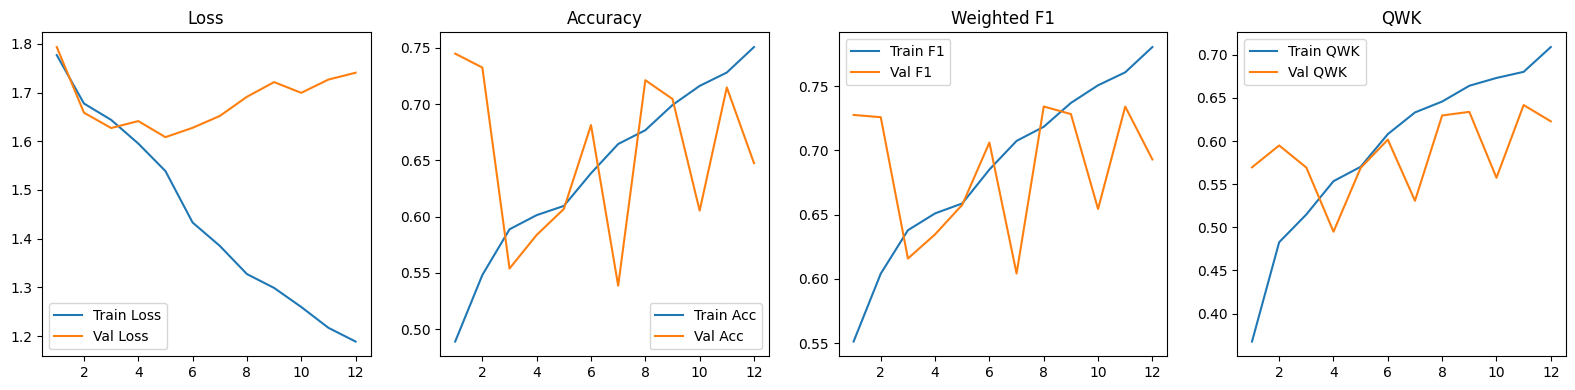

In [75]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(epochs, history["train_f1"], label="Train F1")
plt.plot(epochs, history["val_f1"], label="Val F1")
plt.title("Weighted F1")
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(epochs, history["train_qwk"], label="Train QWK")
plt.plot(epochs, history["val_qwk"], label="Val QWK")
plt.title("QWK")
plt.legend()

plt.tight_layout()
plt.show()

## Load best model and evaluate

In [76]:
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
    saved_thresholds = np.array(checkpoint.get("thresholds", [0.5, 1.5, 2.5, 3.5]), dtype=np.float32)
else:
    model.load_state_dict(checkpoint)
    saved_thresholds = np.array([0.5, 1.5, 2.5, 3.5], dtype=np.float32)

model.eval()

(
    val_loss,
    val_argmax_metrics,
    val_labels,
    val_argmax_preds,
    val_probs,
    val_expected_scores,
) = validate_one_epoch(model, val_loader, criterion, DEVICE)

val_final_preds = apply_thresholds(val_expected_scores, saved_thresholds)
val_final_metrics = compute_metrics(val_labels, val_final_preds)
val_preds = val_final_preds

print("Best Validation Metrics With Saved Thresholds")
print("  Accuracy:", round(val_final_metrics["acc"], 4))
print("  Weighted F1:", round(val_final_metrics["f1"], 4))
print("  QWK:", round(val_final_metrics["qwk"], 4))
print("Argmax Validation QWK:", round(val_argmax_metrics["qwk"], 4))
print("Saved thresholds:", np.round(saved_thresholds, 3).tolist())


Validation:   0%|          | 0/440 [00:00<?, ?it/s]

Best Validation Accuracy: 0.7147736976942783
Best Validation Weighted F1: 0.7341685234096846
Best Validation QWK: 0.6417018338885903


## Classification Report

In [77]:
report_df = pd.DataFrame(
    classification_report(val_labels, val_final_preds, digits=4, output_dict=True)
).T
report_df


              precision    recall  f1-score   support

           0     0.8760    0.8047    0.8389      5162
           1     0.1592    0.2986    0.2077       489
           2     0.5486    0.5170    0.5324      1058
           3     0.4049    0.5714    0.4739       175
           4     0.6098    0.5282    0.5660       142

    accuracy                         0.7148      7026
   macro avg     0.5197    0.5440    0.5238      7026
weighted avg     0.7597    0.7148    0.7342      7026



## Confusion Matrix

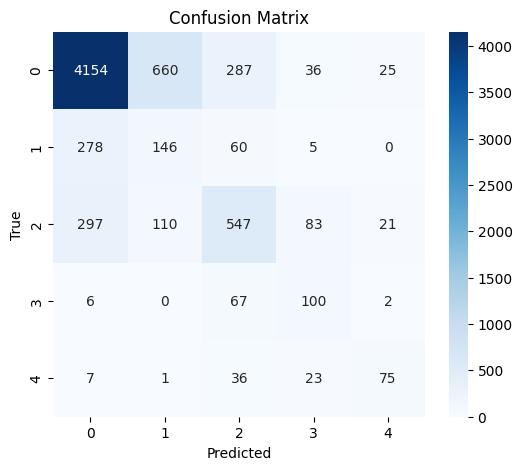

In [78]:
cm = confusion_matrix(val_labels, val_final_preds, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Threshold-Optimized Predictions)")
plt.show()


## Normalised Confusion Matrix

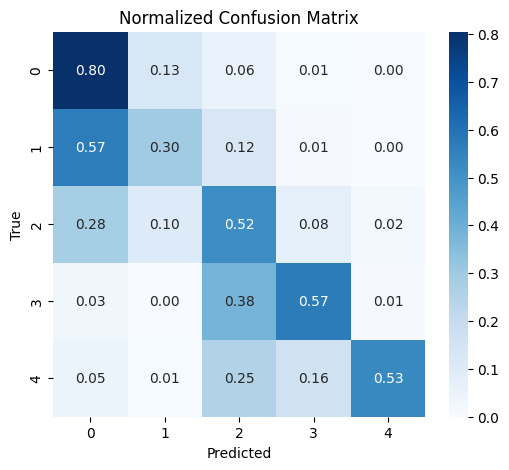

In [79]:
cm = confusion_matrix(val_labels, val_final_preds, labels=[0, 1, 2, 3, 4])
cm_norm = np.divide(
    cm.astype("float"),
    cm.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm, dtype=float),
    where=cm.sum(axis=1, keepdims=True) != 0
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix (Threshold-Optimized Predictions)")
plt.show()


## Support per class bar chart

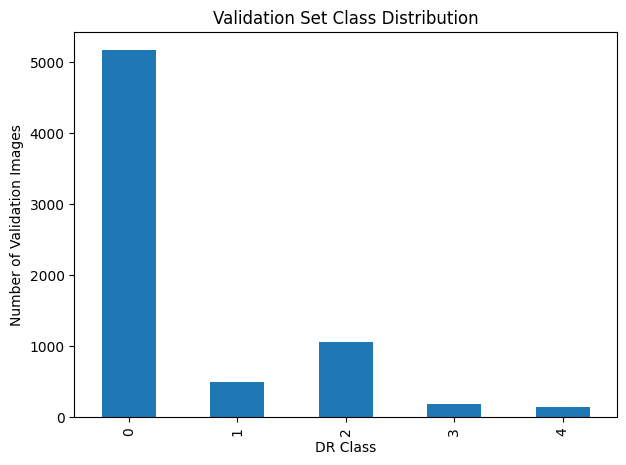

In [80]:
val_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Validation Images")
plt.title("Validation Set Class Distribution")
plt.show()

## Pre-class Error rate plot

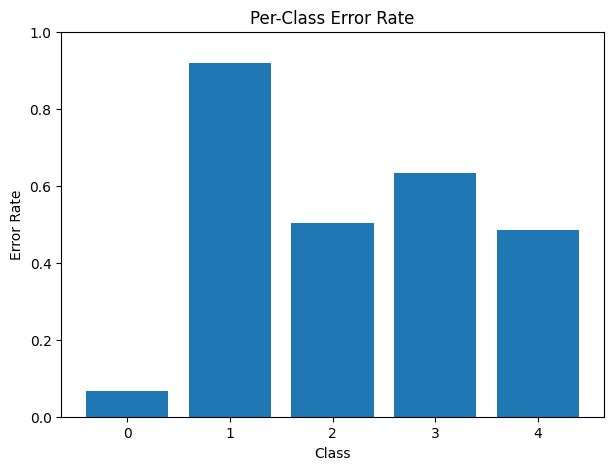

In [81]:
error_rate = 1 - (class_stats["sum"] / class_stats["count"])

plt.figure(figsize=(7,5))
plt.bar(error_rate.index.astype(str), error_rate.values)
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.ylim(0, 1)
plt.title("Per-Class Error Rate")
plt.show()

## Pre-class Recall

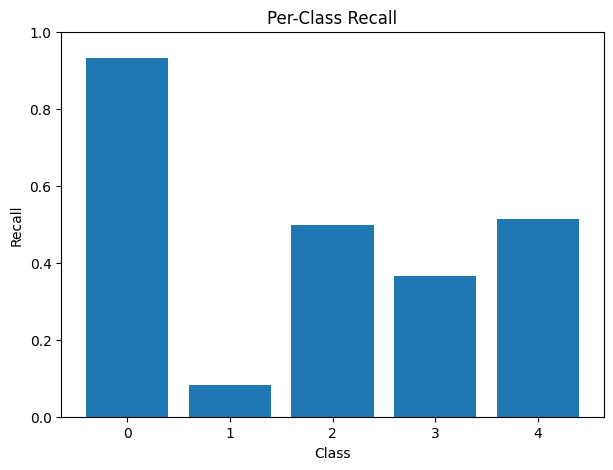

In [82]:
class_recall = class_stats["sum"] / class_stats["count"]

plt.figure(figsize=(7,5))
plt.bar(class_recall.index.astype(str), class_recall.values)
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.title("Per-Class Recall")
plt.show()

## Per-class Precision / Recall / F1 Bar Chart

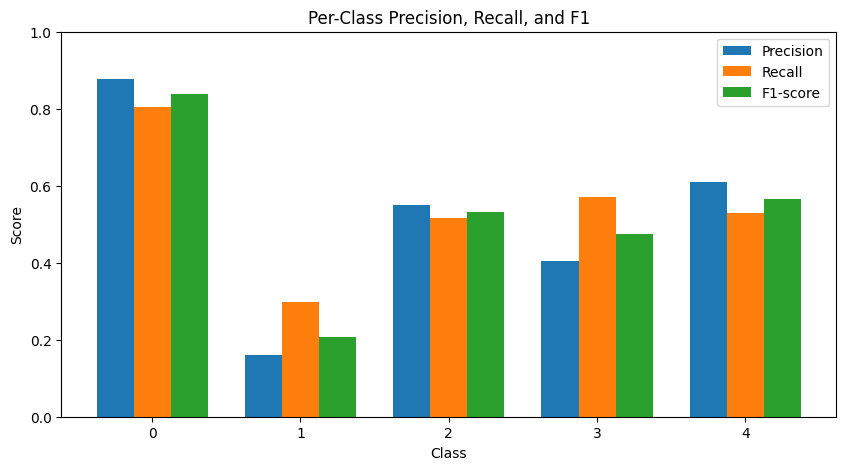

In [83]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(
    val_labels, val_preds, labels=[0,1,2,3,4], zero_division=0
)

classes = ['0', '1', '2', '3', '4']
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.legend()
plt.show()

## Class Distribution Plot

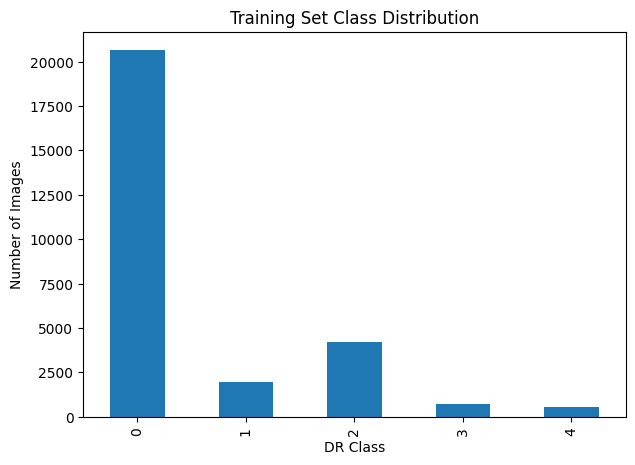

In [84]:
train_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Images")
plt.title("Training Set Class Distribution")
plt.show()

## Prediction distribution vs true distribution

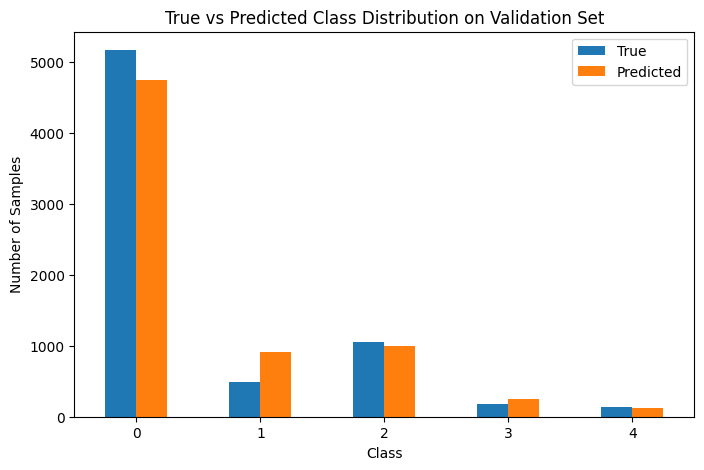

In [85]:
true_counts = pd.Series(val_labels).value_counts().sort_index()
pred_counts = pd.Series(val_preds).value_counts().sort_index()

dist_df = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
}).fillna(0)

dist_df.plot(kind="bar", figsize=(8,5))
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution on Validation Set")
plt.xticks(rotation=0)
plt.show()

## Sample Predictions Grid

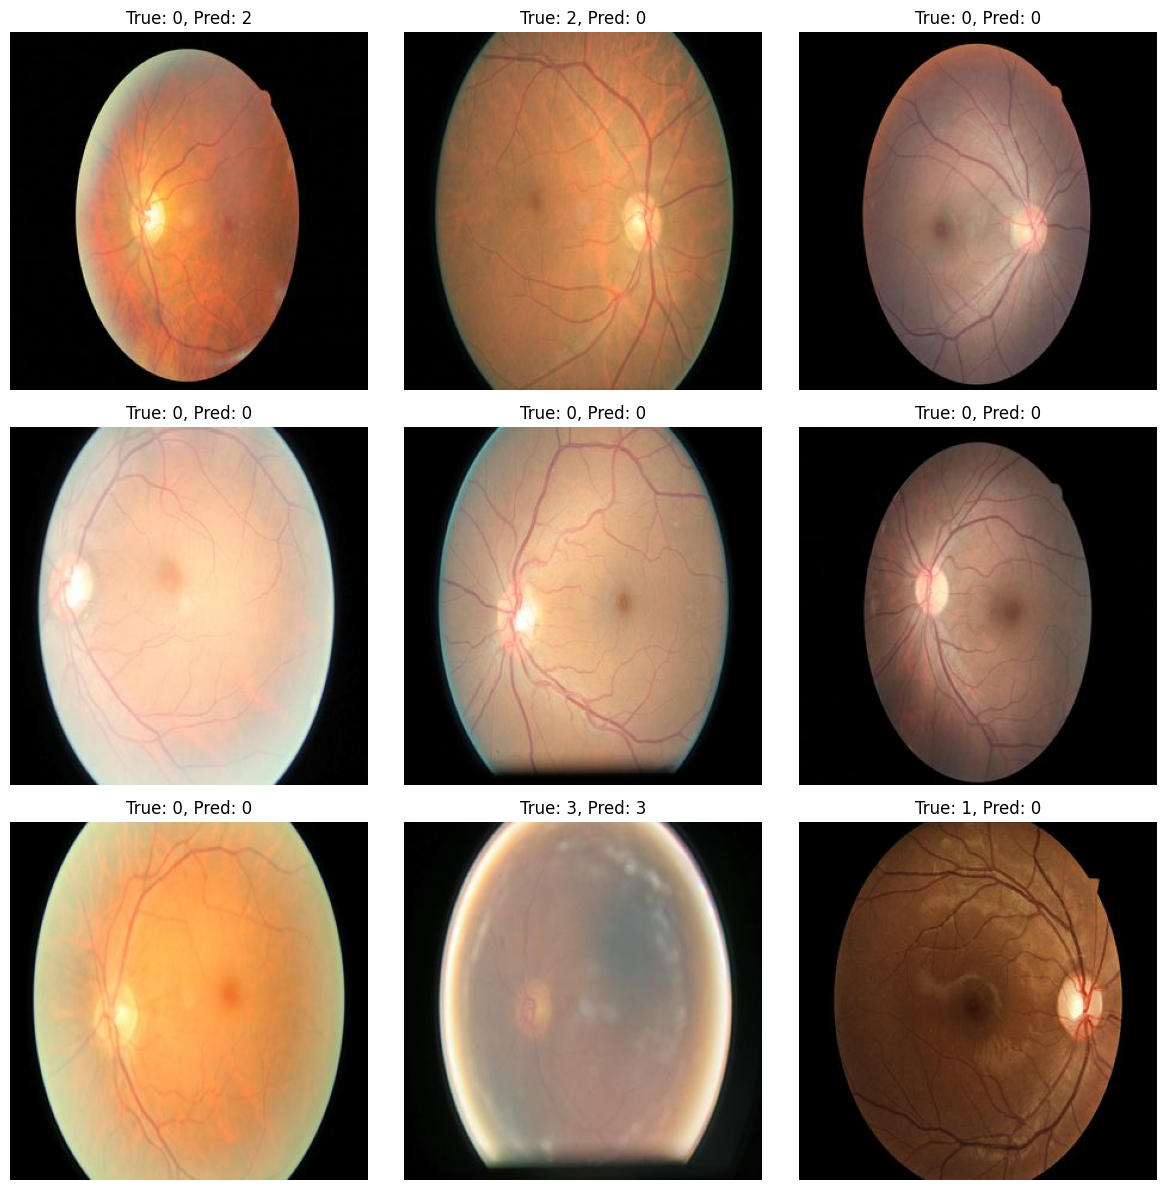

In [86]:
import random
from PIL import Image

sample_indices = random.sample(range(len(val_df)), 9)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(sample_indices, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    # you need corresponding prediction list aligned with val_df
    true_label = row["level"]
    pred_label = val_preds[idx]

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Predictions Grid

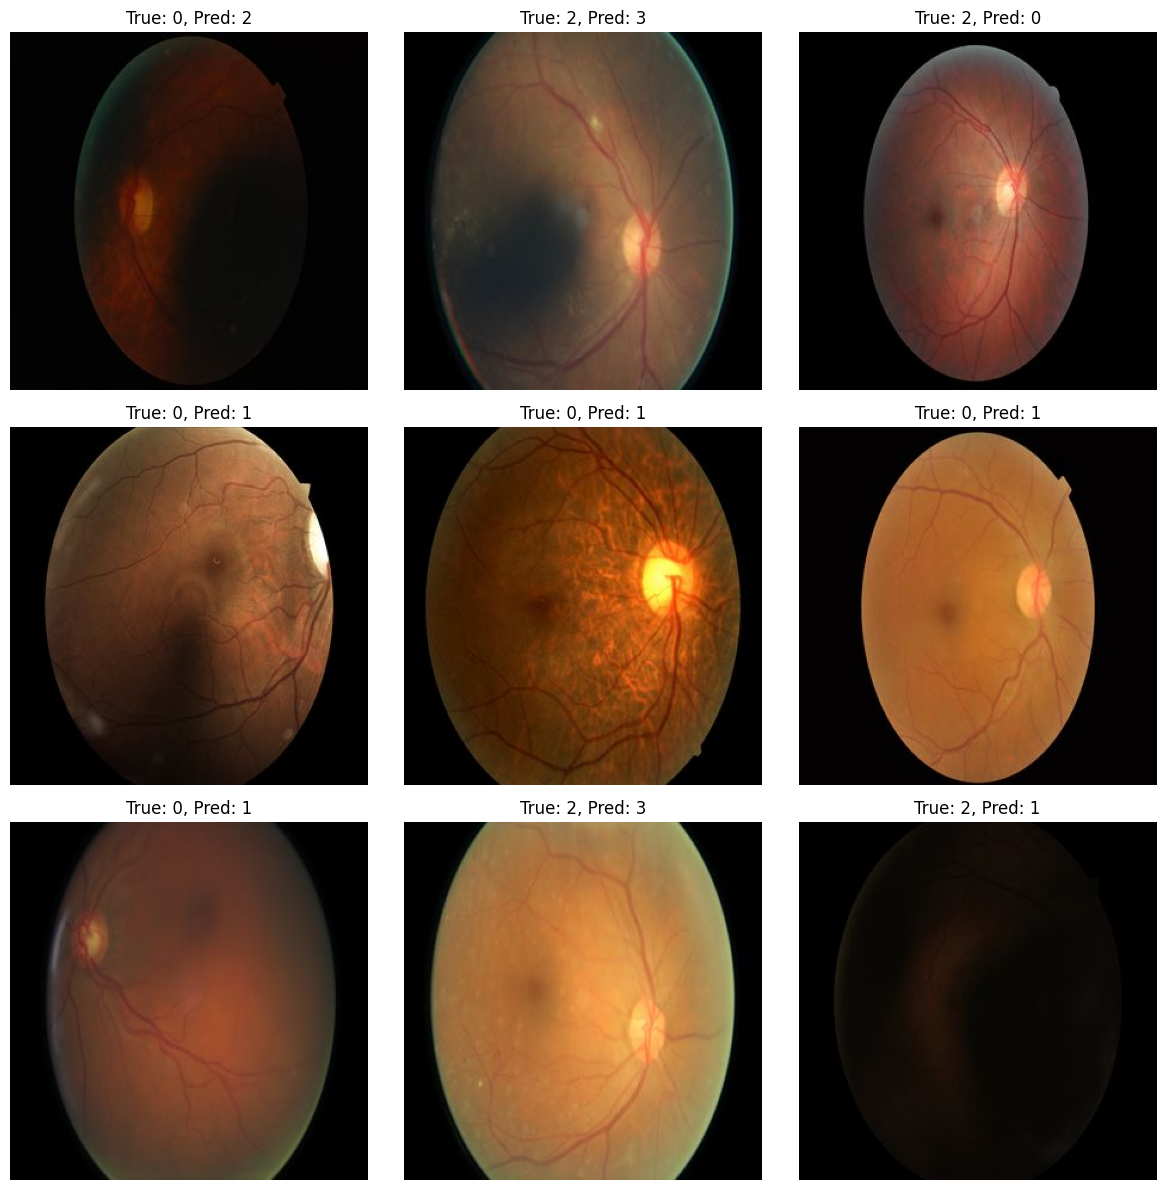

In [87]:
mis_idx = [i for i, (t, p) in enumerate(zip(val_labels, val_preds)) if t != p][:9]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(mis_idx, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {row['level']}, Pred: {val_preds[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [88]:
results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})

mistakes = results_df[results_df["true"] != results_df["pred"]]
pair_counts = mistakes.groupby(["true", "pred"]).size().sort_values(ascending=False)

print(pair_counts.head(10))

true  pred
0     1       660
2     0       297
0     2       287
1     0       278
2     1       110
      3        83
3     2        67
1     2        60
4     2        36
0     3        36
dtype: int64


## Misclassification flow heatmap

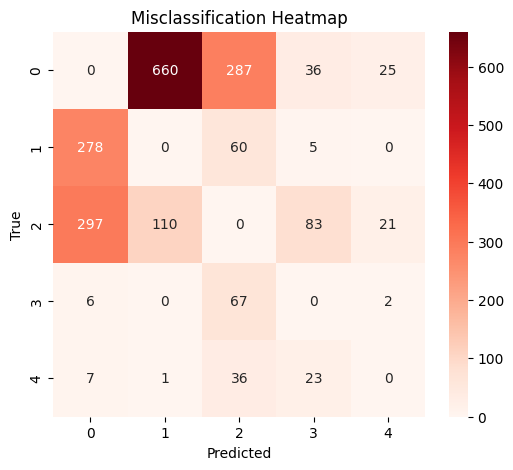

In [89]:
cm = confusion_matrix(val_labels, val_final_preds, labels=[0, 1, 2, 3, 4])
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_offdiag,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[0, 1, 2, 3, 4],
    yticklabels=[0, 1, 2, 3, 4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Misclassification Heatmap (Threshold-Optimized Predictions)")
plt.show()


## Correct vs incorrect predictions by class

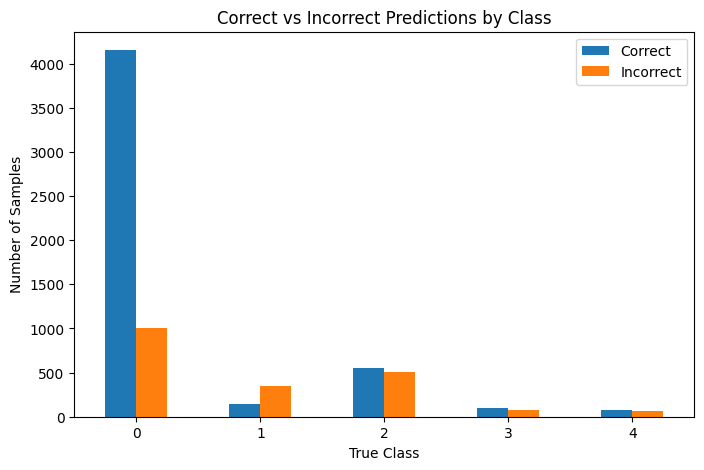

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})
results_df["correct"] = results_df["true"] == results_df["pred"]

class_stats = results_df.groupby("true")["correct"].agg(["sum", "count"])
class_stats["incorrect"] = class_stats["count"] - class_stats["sum"]

class_stats[["sum", "incorrect"]].plot(
    kind="bar",
    figsize=(8,5)
)
plt.xlabel("True Class")
plt.ylabel("Number of Samples")
plt.title("Correct vs Incorrect Predictions by Class")
plt.legend(["Correct", "Incorrect"])
plt.xticks(rotation=0)
plt.show()

## Generalised Gap Plot

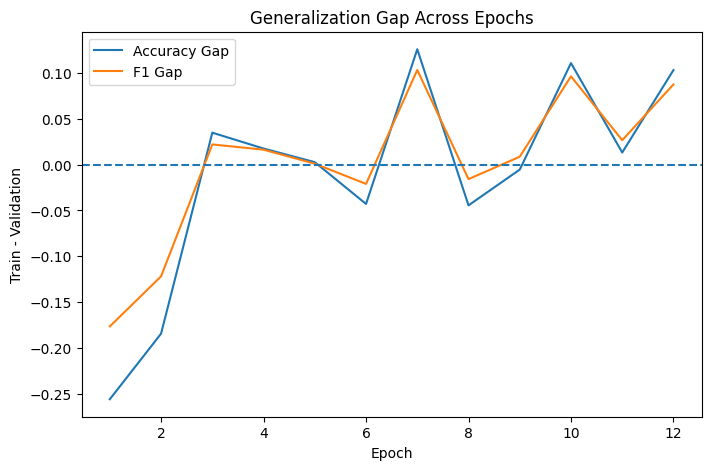

In [91]:
gap_acc = np.array(history_df["train_acc"]) - np.array(history_df["val_acc"])
gap_f1 = np.array(history_df["train_f1"]) - np.array(history_df["val_f1"])

epochs = range(1, len(gap_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, gap_acc, label="Accuracy Gap")
plt.plot(epochs, gap_f1, label="F1 Gap")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Train - Validation")
plt.title("Generalization Gap Across Epochs")
plt.legend()
plt.show()

## Epoch-to-Epoch Improvement Graphs

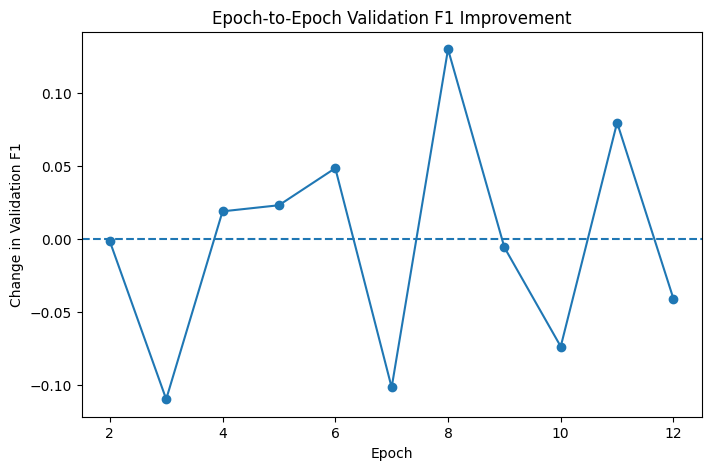

In [92]:
val_f1 = np.array(history_df["val_f1"])
delta_val_f1 = np.diff(val_f1)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_f1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation F1")
plt.title("Epoch-to-Epoch Validation F1 Improvement")
plt.show()

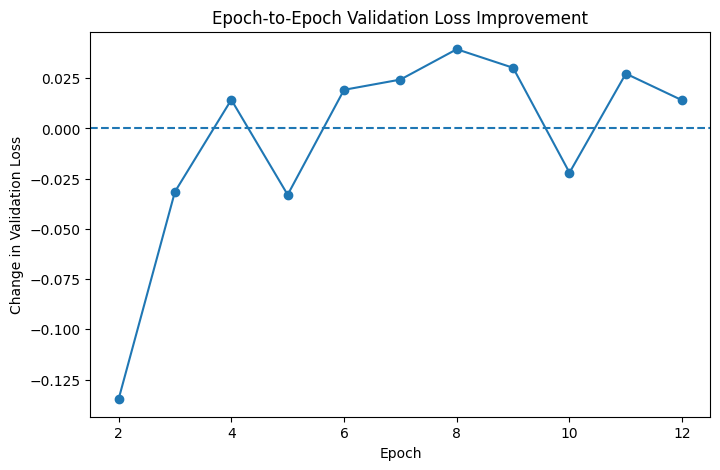

In [93]:
val_loss = np.array(history_df["val_loss"])
delta_val_loss = np.diff(val_loss)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_loss, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Loss")
plt.title("Epoch-to-Epoch Validation Loss Improvement")
plt.show()

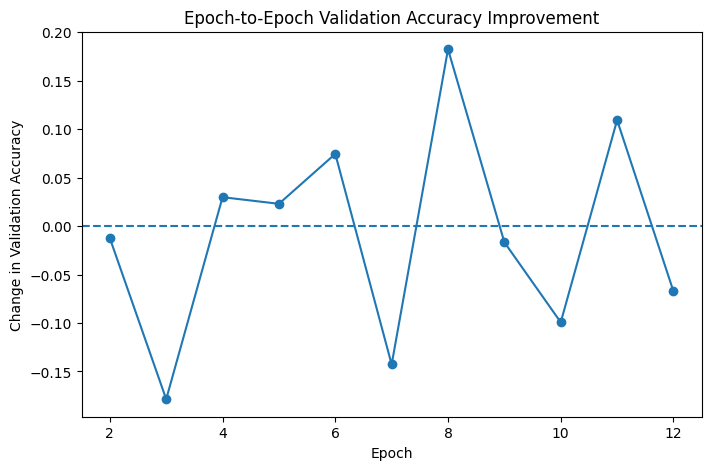

In [94]:
val_acc = np.array(history_df["val_acc"])
delta_val_acc = np.diff(val_acc)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_acc, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Accuracy")
plt.title("Epoch-to-Epoch Validation Accuracy Improvement")
plt.show()

In [95]:
img, label = train_dataset[0]
print(type(img), img.shape, label)

<class 'torch.Tensor'> torch.Size([3, 300, 300]) 0


In [96]:
batch = next(iter(train_loader))
images, labels = batch
print(images.shape, labels.shape)

torch.Size([16, 3, 300, 300]) torch.Size([16])
